GÖREV1=1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say. Tabloyu videodaki gibi görselleştir.

In [4]:
words = open('names.txt', 'r').read().splitlines()

print(f"Toplam isim sayısı: {len(words)}")

print(f"ilk 10 isim: {words[:10]}")

print(f"En kısa isim uzunluğu: {min(len(word) for word in words)}")
print(f"En uzun isim uzunluğu: {max(len(word) for word in words)}")


b = {}

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1
sorted_biagrams = sorted(b.items(), key=lambda kv: kv[1], reverse=True)
print("En çok tekrar eden harf ikilileri:")
for biagram, count in sorted_biagrams[:10]:
    print(f"{biagram}: {count}")        


Toplam isim sayısı: 32033
ilk 10 isim: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
En kısa isim uzunluğu: 2
En uzun isim uzunluğu: 15
En çok tekrar eden harf ikilileri:
('n', '.'): 6763
('a', '.'): 6640
('a', 'n'): 5438
('.', 'a'): 4410
('e', '.'): 3983
('a', 'r'): 3264
('e', 'l'): 3248
('r', 'i'): 3033
('n', 'a'): 2977
('.', 'k'): 2963


In [6]:
chars = sorted(list(set(''.join(words)))) #Benzersiz karakterleri sıralı listeye alıyoruz

s2i = {s: i+1 for i, s in enumerate(chars)} #Karakterleri indexlere eşitliyoruz.

s2i['.'] = 0 # Başlangıç ve bitiş karakteri için index 0'ı kullanıyoryz.

i2s = {i: s for s, i in s2i.items()}

print(f"Sözlük boyutu: {len(s2i)}")
print(f"Örnek eşleşmeler: '.' -> {s2i['.']}, 'a' -> {s2i['a']}, 'z' -> {s2i['z']}")




Sözlük boyutu: 27
Örnek eşleşmeler: '.' -> 0, 'a' -> 1, 'z' -> 26


Pytorch ile sayım

In [7]:
import torch


N = torch.zeros((27,27), dtype=torch.float32)


for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        N[ix1, ix2] += 1

print(f"Tensor boyutu: {N.shape}")
print(f"Toplam sayılan biagram sayısı: {N.sum().item()}")
        

Tensor boyutu: torch.Size([27, 27])
Toplam sayılan biagram sayısı: 228146.0


Görselleştirme

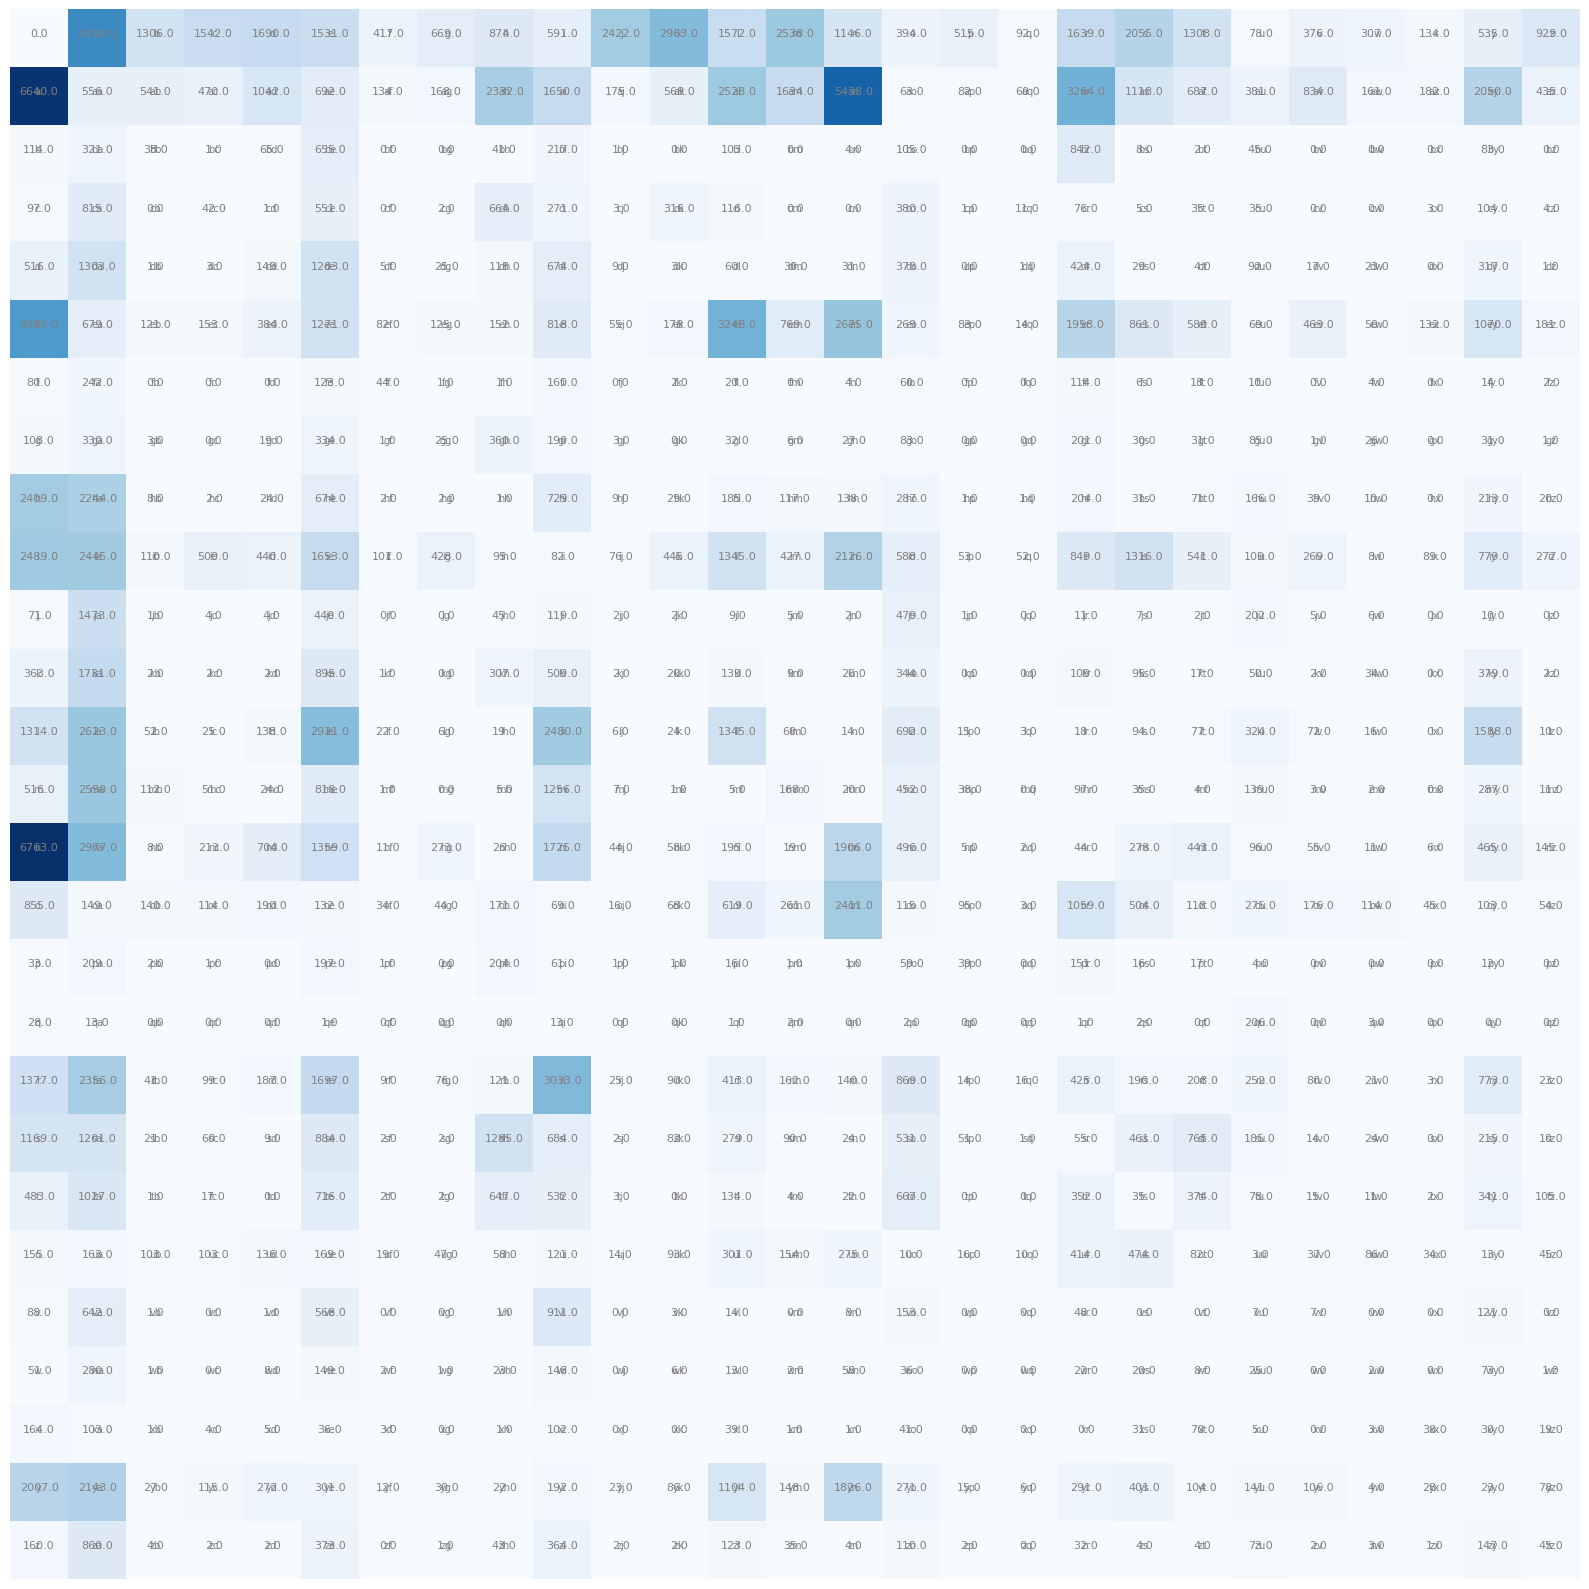

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')


for i in range(27):
    for j in range(27):
        chstr = i2s[i] + i2s[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=7)

        plt.text(
            j,i, N[i, j].item(), ha="center", va="bottom", color="gray", fontsize=7)
plt.axis('off')
plt.tight_layout()
plt.show()        
    